In [1]:
import pandas as pd

df = pd.read_csv("../results/test_with_three_way_labels.csv")

display(df.head())
print(df.columns)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,y_true,y_pred,p_class1,decision
0,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050,0,0,5.888242e-08,Confirm_Malignant
1,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083,1,1,9.999887e-01,Confirm_Benign
2,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830,0,0,6.410825e-03,Confirm_Malignant
3,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469,1,1,5.335085e-01,Uncertain
4,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115,0,0,6.525001e-10,Confirm_Malignant


Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'y_true', 'y_pred', 'p_class1', 'decision'],
      dtype='object')


In [3]:
# Baseline wrong predictions
df["baseline_wrong"] = df["y_true"] != df["y_pred"]

# Wrong AND uncertain
wrong_uncertain = df[
    (df["baseline_wrong"] == True) &
    (df["decision"] == "Uncertain")
]

print("Total baseline errors:", df["baseline_wrong"].sum())
print("Baseline errors deferred as Uncertain:", len(wrong_uncertain))

Total baseline errors: 2
Baseline errors deferred as Uncertain: 2


In [4]:
print(
    df.groupby("decision")["p_class1"].describe()
)

                   count      mean       std           min           25%  \
decision                                                                   
Confirm_Benign      58.0  0.988628  0.019776  9.165881e-01  9.886444e-01   
Confirm_Malignant   40.0  0.014728  0.043887  1.632997e-23  6.136014e-07   
Uncertain           16.0  0.724857  0.201601  3.518803e-01  5.442403e-01   

                        50%       75%       max  
decision                                         
Confirm_Benign     0.998766  0.999816  1.000000  
Confirm_Malignant  0.000038  0.000800  0.187989  
Uncertain          0.843522  0.895012  0.908728  


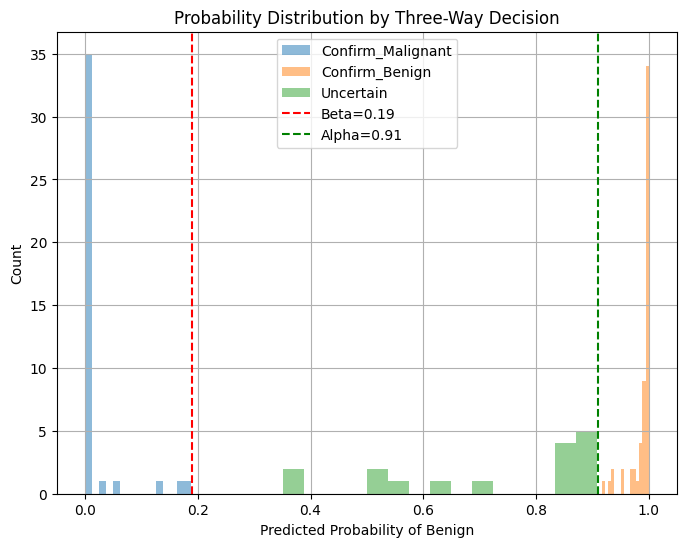

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for decision in df["decision"].unique():
    subset = df[df["decision"] == decision]
    plt.hist(
        subset["p_class1"],
        bins=15,
        alpha=0.5,
        label=decision
    )

plt.axvline(0.19, color='red', linestyle='--', label='Beta=0.19')
plt.axvline(0.91, color='green', linestyle='--', label='Alpha=0.91')

plt.xlabel("Predicted Probability of Benign")
plt.ylabel("Count")
plt.title("Probability Distribution by Three-Way Decision")
plt.legend()
plt.grid(True)

plt.savefig("../results/uncertain_probability_distribution.png", dpi=300, bbox_inches="tight")

plt.show()